# Ejercicio Incremental — California Housing

Ejercicio integrador del módulo: sobre el dataset **California housing** se recorre el flujo completo — EDA, limpieza (nulos y outliers), preparación (escalado) y una **progresión de modelos de regresión** (Regresión lineal → Árbol de decisión → SVR → Random Forest → XGBoost), cerrando con **validación cruzada** y **ajuste de hiperparámetros** (Grid/Randomized Search).

> Notebook extra (no forma parte de la práctica evaluada). Métrica: se imprime R², MSE y `RMSE*100`.

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga y análisis exploratorio (EDA)

Dataset **California housing** (`housing.csv`): predecir `median_house_value`. Exploramos estructura, tipos y distribución geográfica (lat/lon).

In [4]:
df=pd.read_csv("../datasets/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [6]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

In [7]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [8]:
df.shape

(20640, 10)

In [9]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


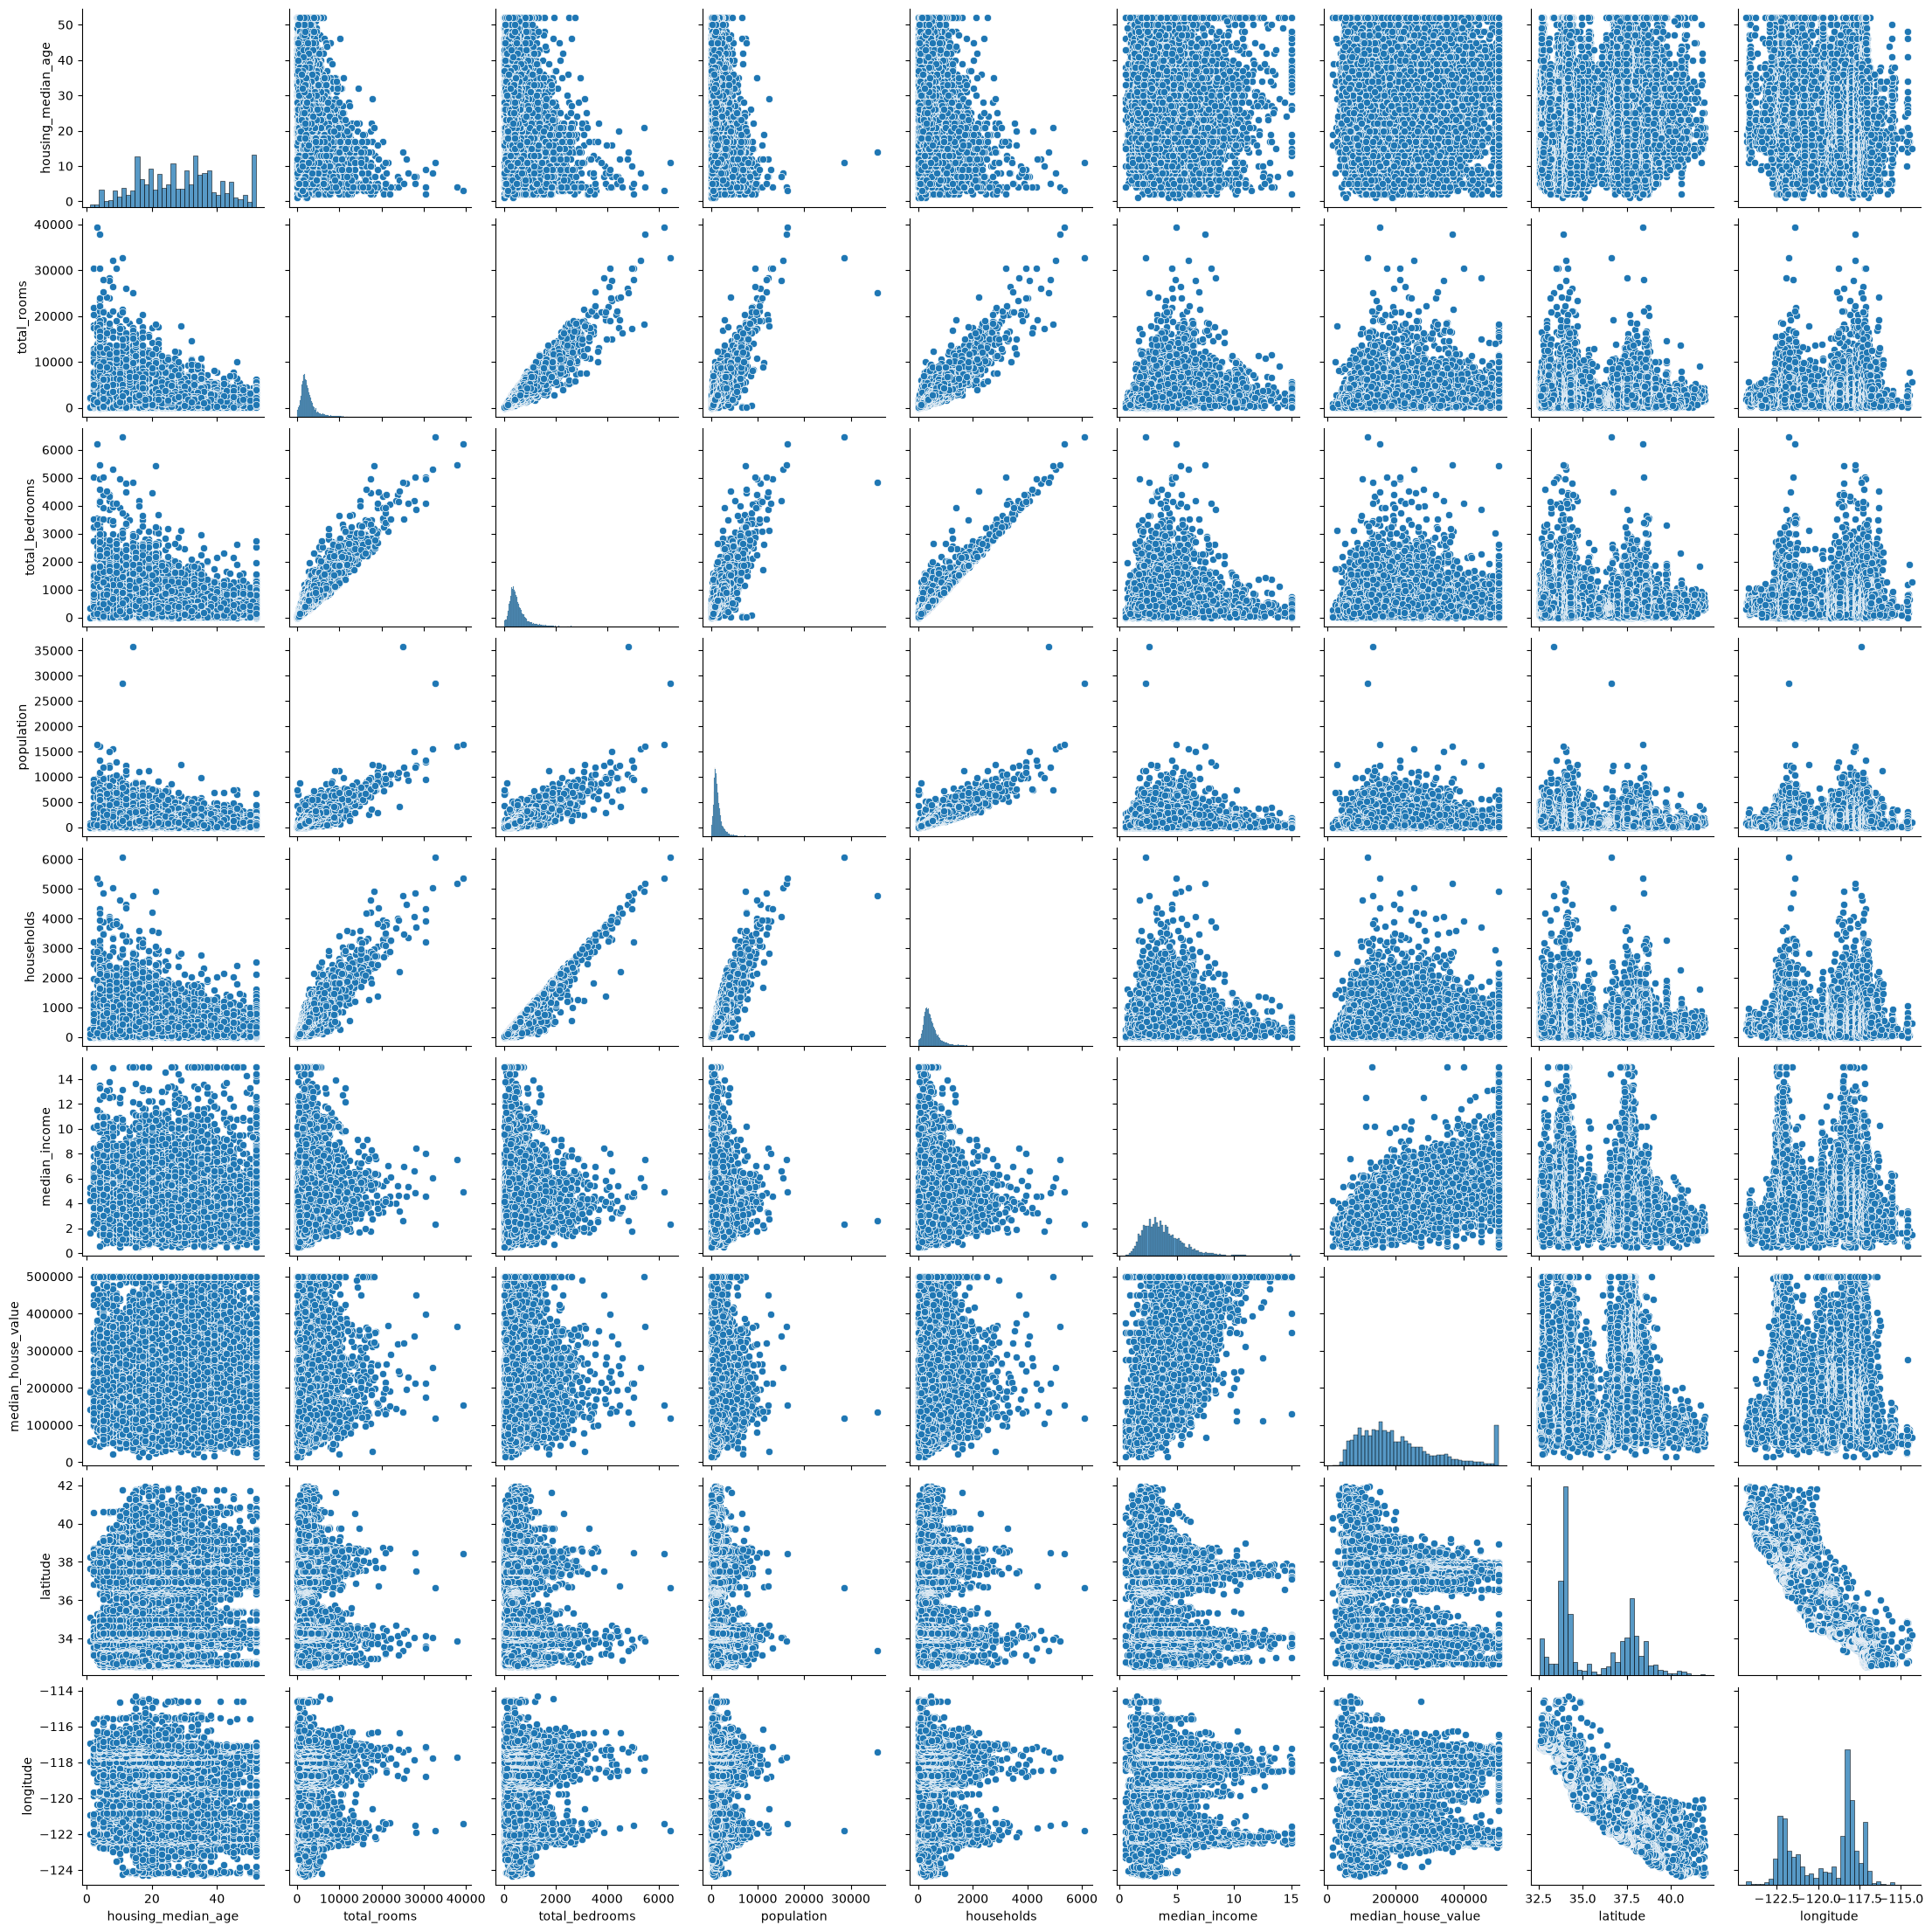

In [10]:
df2=df[['housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value','latitude','longitude']]
sns.pairplot(data=df2)

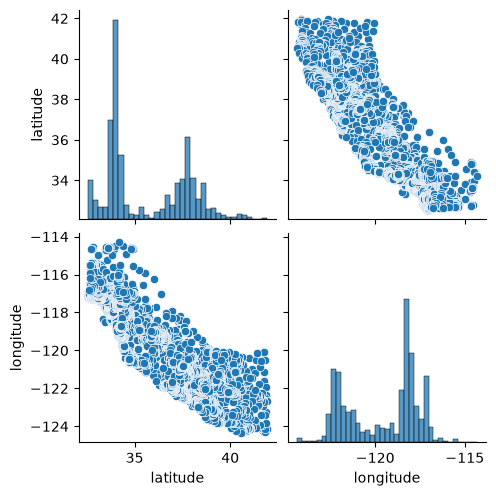

In [11]:
df2=df[['latitude','longitude']]
sns.pairplot(data=df2)

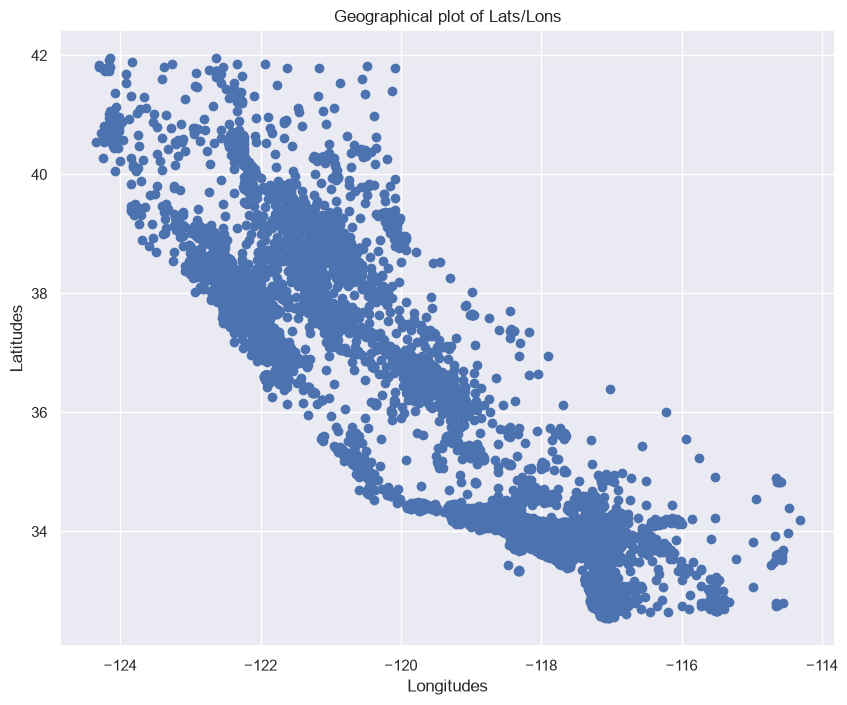

In [12]:
sns.set()
plt.figure(figsize=(10,8))
plt.scatter('longitude','latitude',data=df)
plt.ylabel('Latitudes')
plt.xlabel('Longitudes')
plt.title('Geographical plot of Lats/Lons')
plt.show()

<Figure size 1000x700 with 0 Axes>

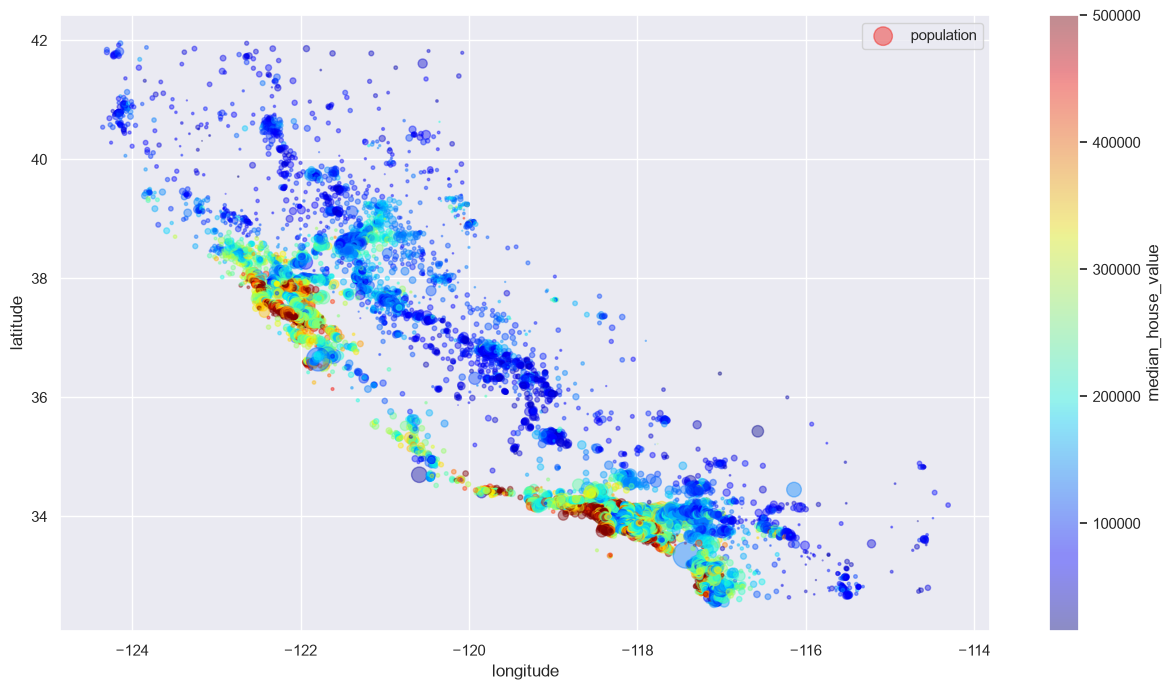

In [13]:
plt.figure(figsize=(10,7));
df.plot(kind="scatter",x="longitude",y="latitude",alpha=0.4, s=df['population']/100,label='population',
        figsize=(15,8),c="median_house_value",colormap=plt.get_cmap("jet"),colorbar=True);
plt.legend();

## 2. Valores faltantes

`total_bedrooms` tiene nulos; los imputamos con la media.

In [14]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [15]:
(round(df.isna().sum()*100/df.shape[0],2)).astype(str) + "%"

longitude             0.0%
latitude              0.0%
housing_median_age    0.0%
total_rooms           0.0%
total_bedrooms        1.0%
population            0.0%
households            0.0%
median_income         0.0%
median_house_value    0.0%
ocean_proximity       0.0%
dtype: str

In [16]:
df_missing =df.isna().melt(value_name="missing")

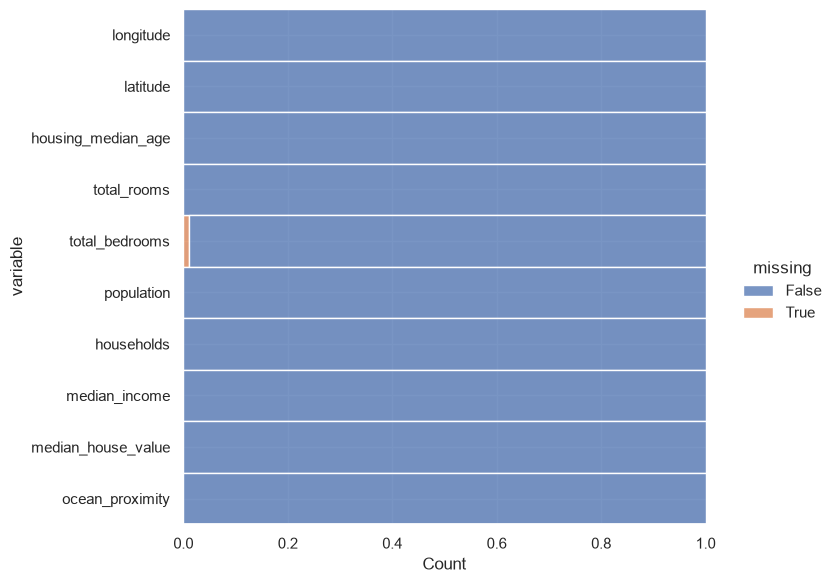

In [17]:
sns.displot(data=df_missing,y="variable",hue="missing",multiple="fill",aspect=1.25,height=6)

In [ ]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(int(df['total_bedrooms'].mean()))

In [19]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## 3. Duplicados y outliers

Verificamos duplicados y recortamos outliers con el percentil 0.9 de las variables continuas.

In [20]:
df.duplicated().sum()

np.int64(0)

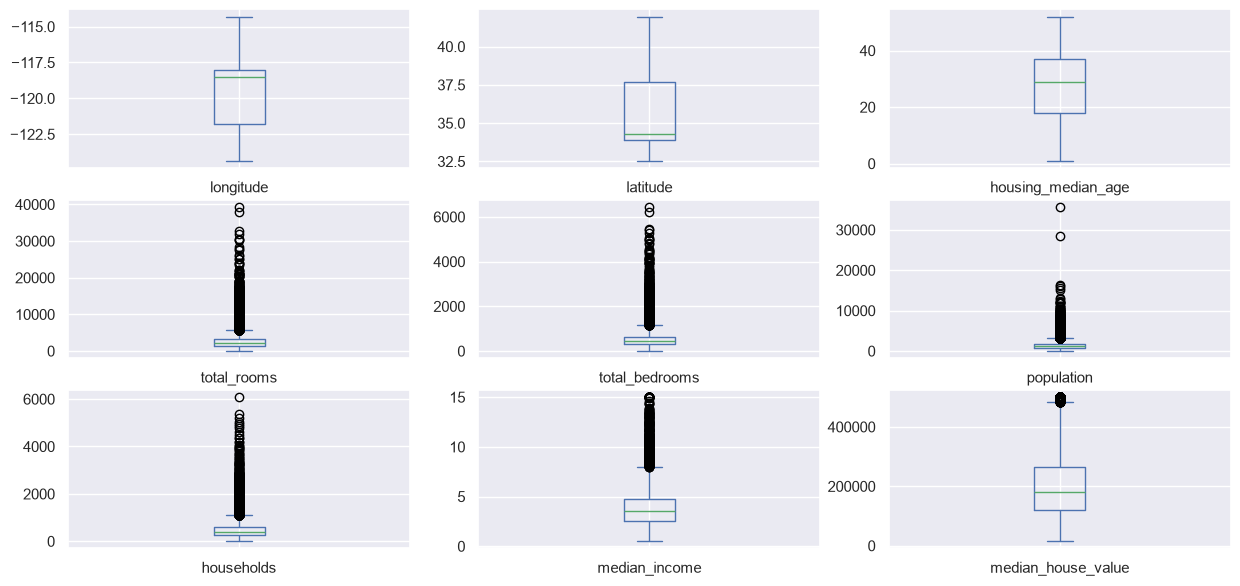

In [21]:
df.plot(kind='box',subplots=True,layout=(3,3),figsize=(15,7))
plt.show()

In [22]:
columns=['total_rooms','total_bedrooms','population','households','median_income']

for column in columns:
    df=df[df[column]<df[column].quantile(0.9)]

In [23]:
df.shape

(12047, 10)

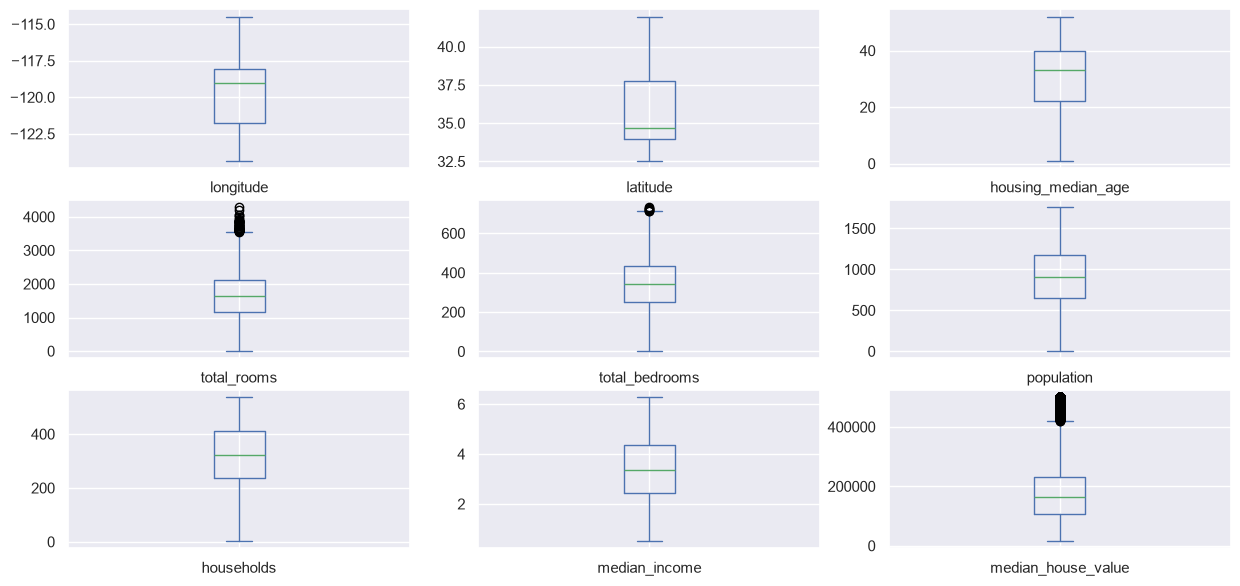

In [24]:
df.plot(kind='box',subplots=True,layout=(3,3),figsize=(15,7))
plt.show()

## 4. Variables categóricas y distribuciones

`ocean_proximity`, rangos de ingreso y de valor de vivienda.

In [25]:
ocean_values=df["ocean_proximity"].value_counts()
ocean_values

ocean_proximity
<1H OCEAN     4929
INLAND        4293
NEAR OCEAN    1472
NEAR BAY      1348
ISLAND           5
Name: count, dtype: int64

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x="ocean_proximity",data=df,order=ocean_values.index)

for i in range(ocean_values.shape[0]):
    count=ocean_values.iloc[i]
    strt='{:0.2f}%'.format(100*count/df.shape[0])
    plt.text(i,count+100,strt,ha='center',color='black',fontsize=14)

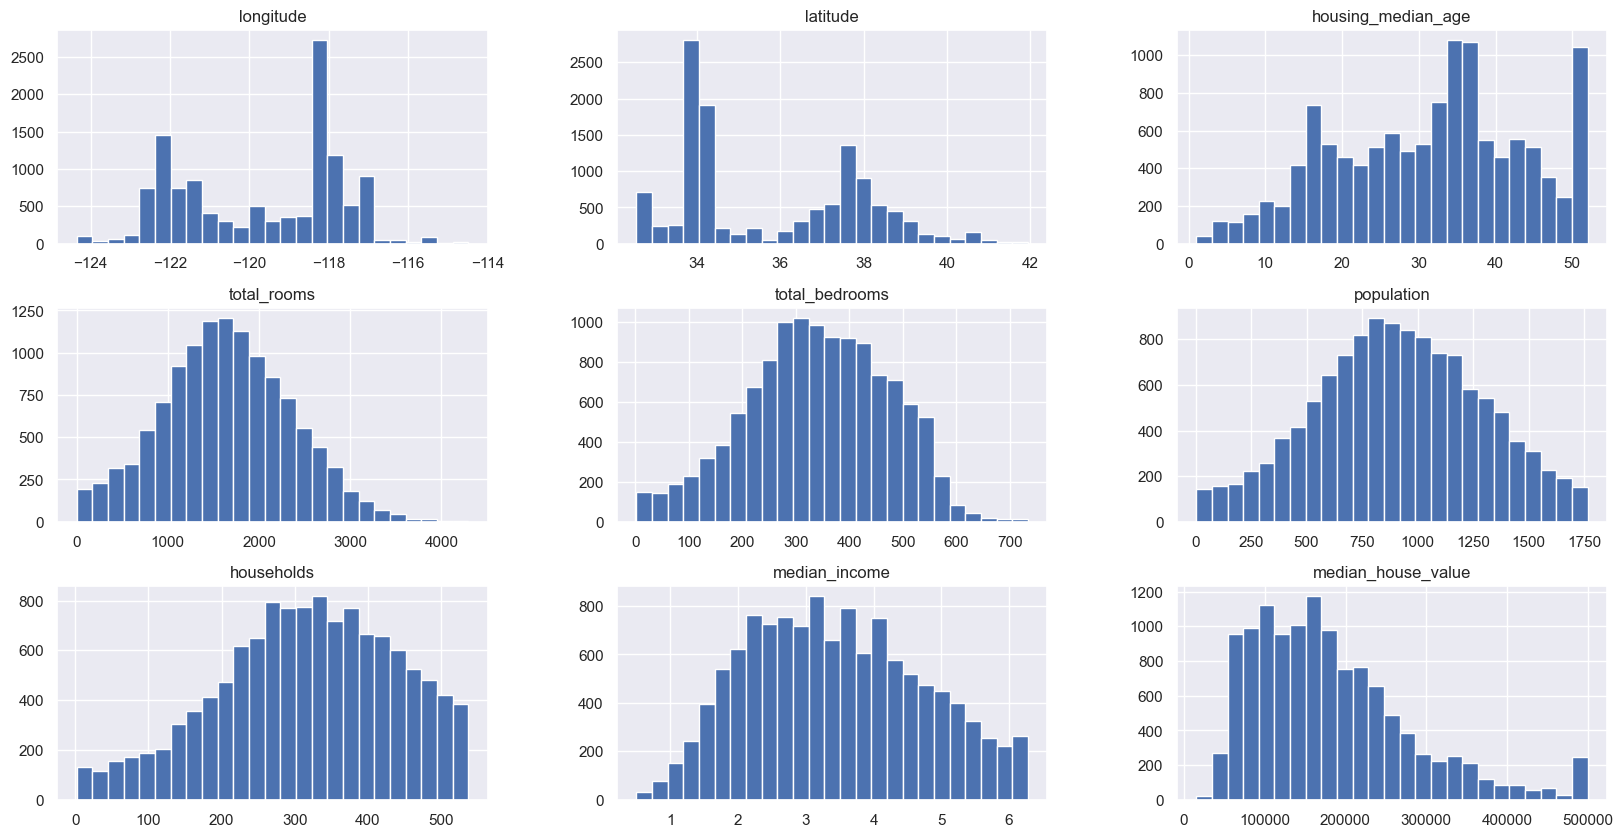

In [ ]:
df.hist(bins=25,figsize=(20,10));

Text(0.5, 1.0, 'Linear correlation Median Income/Median House Value')

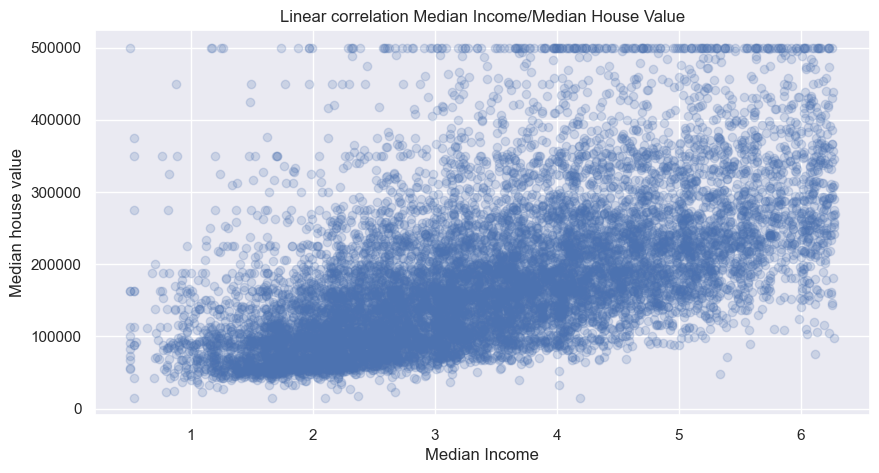

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(df["median_income"],df["median_house_value"],alpha=0.2)
plt.xlabel('Median Income')
plt.ylabel('Median house value')
plt.title('Linear correlation Median Income/Median House Value')

Text(0.5, 1.0, 'Distribución de Ingresos')

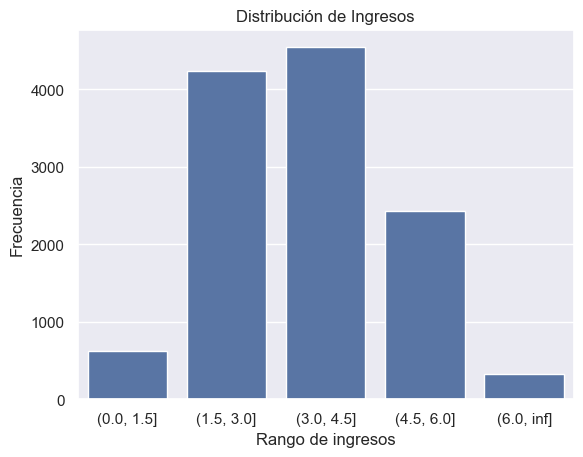

In [ ]:
income_bins=pd.cut(df["median_income"],bins=[0,1.5,3,4.5,6,np.inf])
sns.countplot(x=income_bins)

plt.xlabel("Rango de ingresos")
plt.ylabel("Frecuencia")
plt.title("Distribución de Ingresos")

Text(0.5, 1.0, 'Distribución de Ingresos')

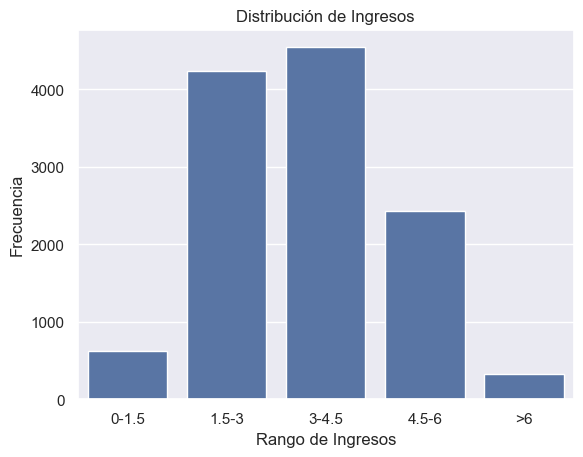

In [ ]:
income_bins=pd.cut(df["median_income"],bins=[0,1.5,3,4.5,6,np.inf],labels=["0-1.5","1.5-3","3-4.5","4.5-6",">6"])
sns.countplot(x=income_bins)

plt.xlabel("Rango de Ingresos")
plt.ylabel("Frecuencia")
plt.title("Distribución de Ingresos")

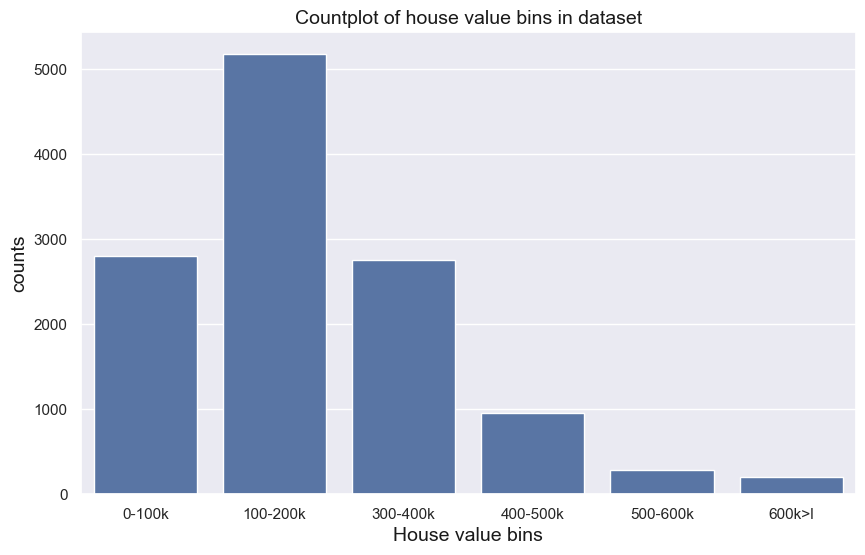

In [ ]:
house_value_bins=pd.cut(x=df["median_house_value"],bins=(-np.inf,100000,200000,300000,400000,500000,np.inf),
                        labels=('0-100k','100-200k','300-400k','400-500k','500-600k','600k>l'))

plt.figure(figsize=(10,6))
sns.countplot(x=house_value_bins)
plt.title("Countplot of house value bins in dataset",fontsize=14,c='k')
plt.xlabel("House value bins",fontsize=14,c='k')
plt.ylabel('counts',fontsize=14,c='k')
plt.show()

## 5. Preparación de datos

Seleccionamos features numéricas, separamos train/test y **escalamos** con `MinMaxScaler`.

In [ ]:
target="median_house_value"

In [ ]:
df=df[['housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value']]

x=df[['housing_median_age','total_rooms','total_bedrooms','population','households','median_income']]

y=df[target]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [ ]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(8516, 6) (3650, 6) (8516,) (3650,)


In [ ]:
x_train.describe()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,8516.000000,8516.000000,8516.000000,8516.000000,8516.00000,8516.000000
mean,31.491310,1644.846407,339.128934,908.318342,314.21853,3.439528
std,12.175659,710.640830,133.360206,380.258879,122.77461,1.291813
min,1.000000,2.000000,2.000000,3.000000,2.00000,0.499900
25%,22.000000,1165.000000,251.000000,648.000000,233.75000,2.412950
50%,33.000000,1621.000000,341.500000,906.500000,320.00000,3.348000
75%,40.000000,2121.000000,438.000000,1178.000000,408.00000,4.389700
max,52.000000,4293.000000,734.000000,1766.000000,537.00000,6.277800


In [ ]:
from sklearn.preprocessing import MinMaxScaler
minmax_scaler=MinMaxScaler()
x_train=minmax_scaler.fit_transform(x_train)
x_test=minmax_scaler.transform(x_test)
x=minmax_scaler.transform(x)

In [ ]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(8516, 6) (3650, 6) (8516,) (3650,)


## 6. Modelo base: Regresión lineal

In [ ]:
from sklearn import linear_model

reg=linear_model.LinearRegression()

In [ ]:
reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
reg.score(x_train,y_train)

0.46307679247492106

In [ ]:
reg.intercept_

-21957.579349533742

In [ ]:
reg.coef_

array([  78859.09638583, -252416.3181715 ,  176025.89777962,
       -191812.41090221,  194521.56388687,  309763.10311355])

In [ ]:
y_predict=reg.predict(x_test)

In [ ]:
y_predict

array([217692.80098215, 126236.55665006, 127099.87327359, ...,
       295260.41509319, 205002.08008718, 249350.74665431])

In [ ]:
y_test.values

array([277300., 130100., 118100., ..., 261900., 169700., 313900.])

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

reg_score=r2_score(y_test,y_predict)
print(reg_score)

mse=mean_squared_error(y_test,y_predict)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.47607290247854206
5013437346.03427
7080563.075091041


## 7. Árbol de decisión

Probamos distintas `max_depth` y visualizamos el árbol.

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [ ]:
tree_mod=DecisionTreeRegressor()

In [ ]:
tree_mod.fit(x_train,y_train)

DecisionTreeRegressor()

In [ ]:
preds_tree=tree_mod.predict(x_test)

In [ ]:
reg_score=r2_score(y_test,preds_tree)
print(reg_score)

mse=mean_squared_error(y_test,preds_tree)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.05591416987995157
9033919377.288492
9504693.2498048


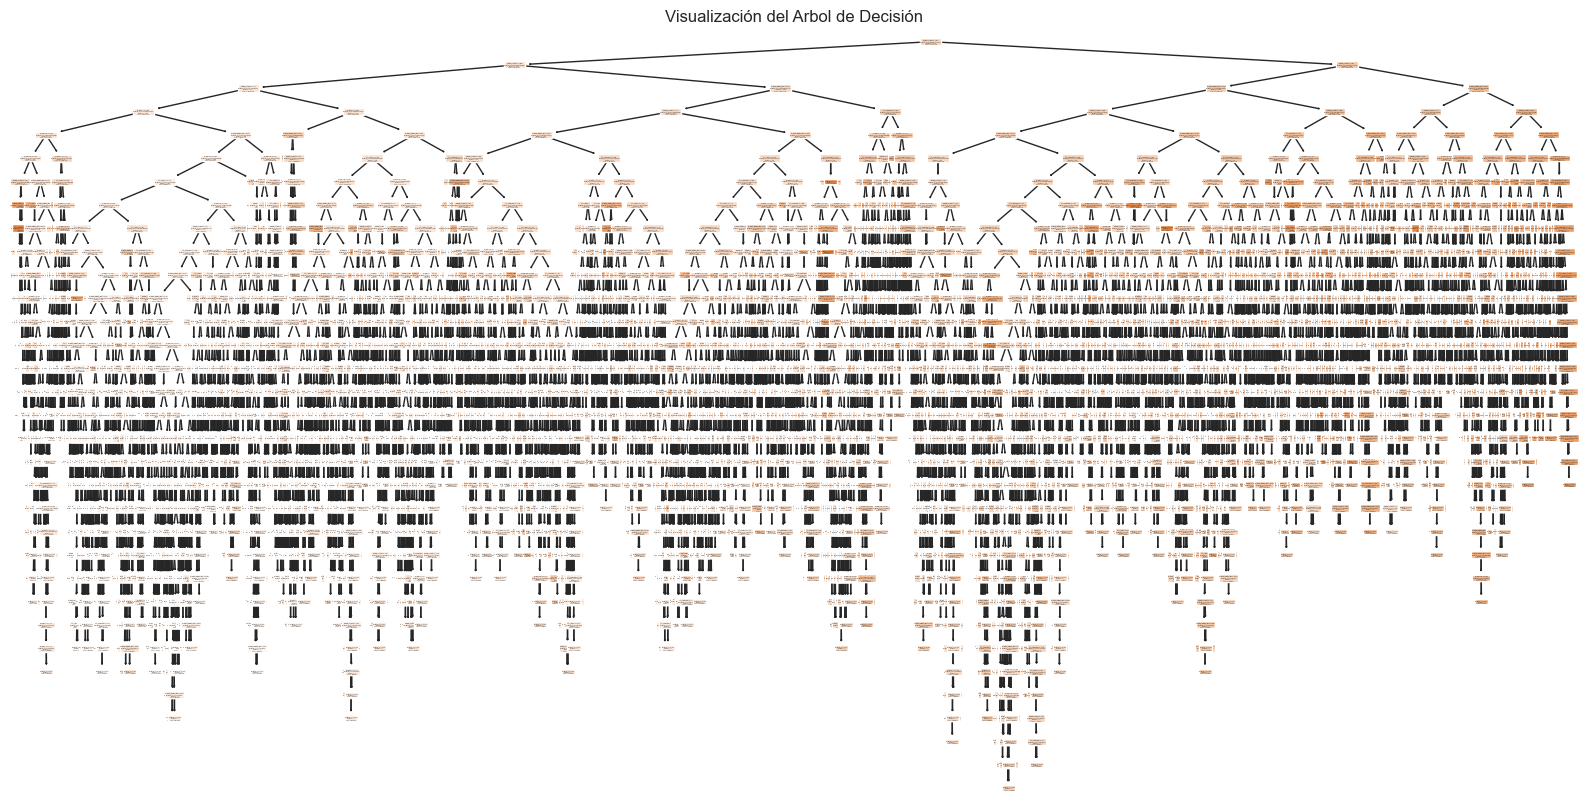

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(tree_mod,filled=True,feature_names=['housing_median_age','total_rooms','total_bedrooms','population','households','median_income'],class_names=True)
plt.title("Visualización del Arbol de Decisión")
plt.show()

In [ ]:
tree_mod=DecisionTreeRegressor(max_depth=3)
tree_mod.fit(x_train,y_train)
preds_tree=tree_mod.predict(x_test)



reg_score=r2_score(y_test,preds_tree)
print(reg_score)

mse=mean_squared_error(y_test,preds_tree)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.38349739392039706
5899288667.962721
7680682.696194864


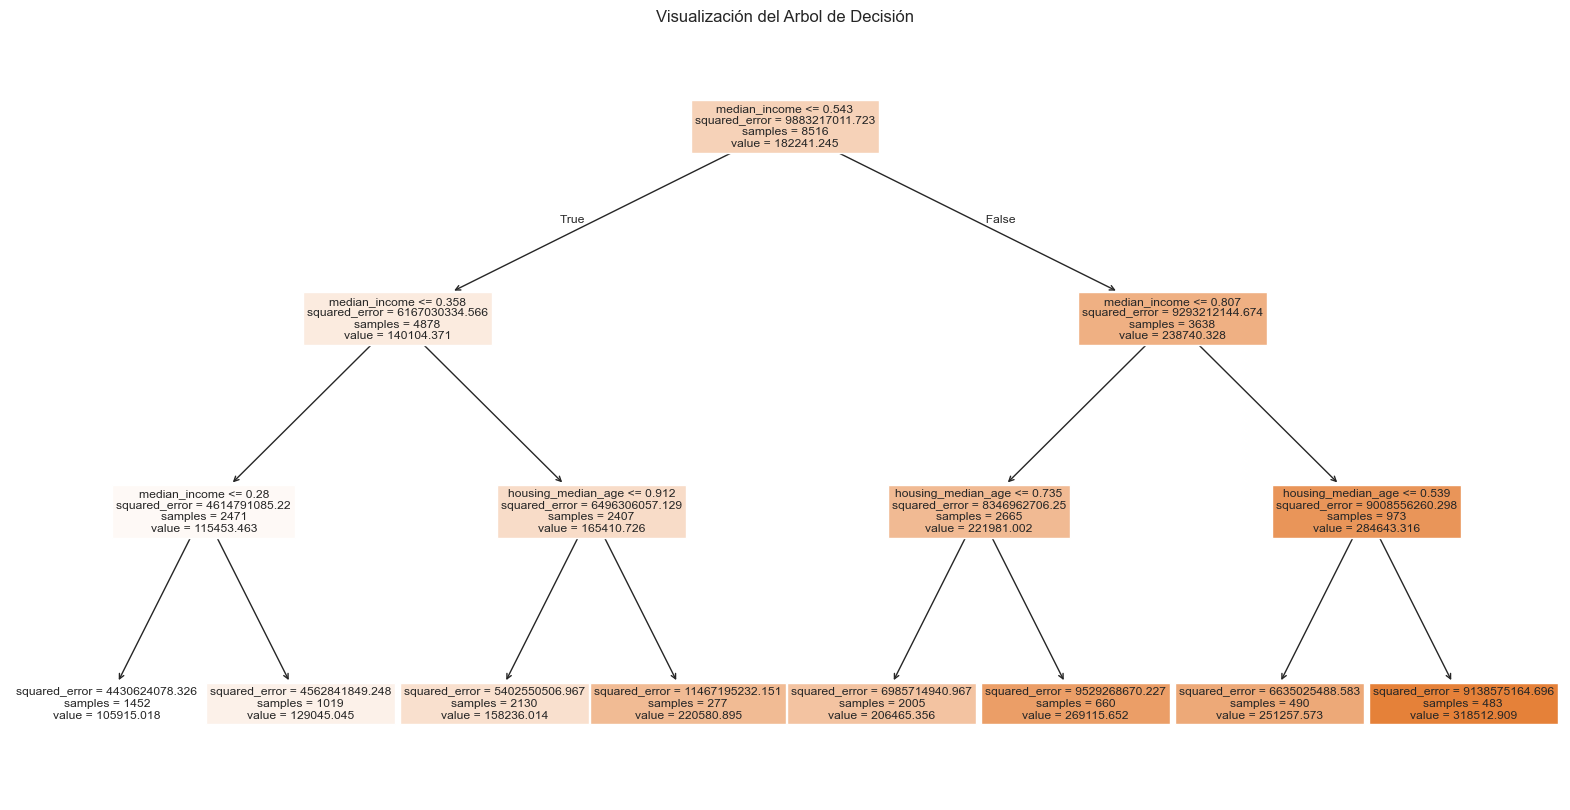

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(tree_mod,filled=True,feature_names=['housing_median_age','total_rooms','total_bedrooms','population','households','median_income'],class_names=True)
plt.title("Visualización del Arbol de Decisión")
plt.show()

In [ ]:
tree_mod=DecisionTreeRegressor(max_depth=2)
tree_mod.fit(x_train,y_train)
preds_tree=tree_mod.predict(x_test)



reg_score=r2_score(y_test,preds_tree)
print(reg_score)

mse=mean_squared_error(y_test,preds_tree)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.32358223325760627
6472614433.095868
8045256.014009666


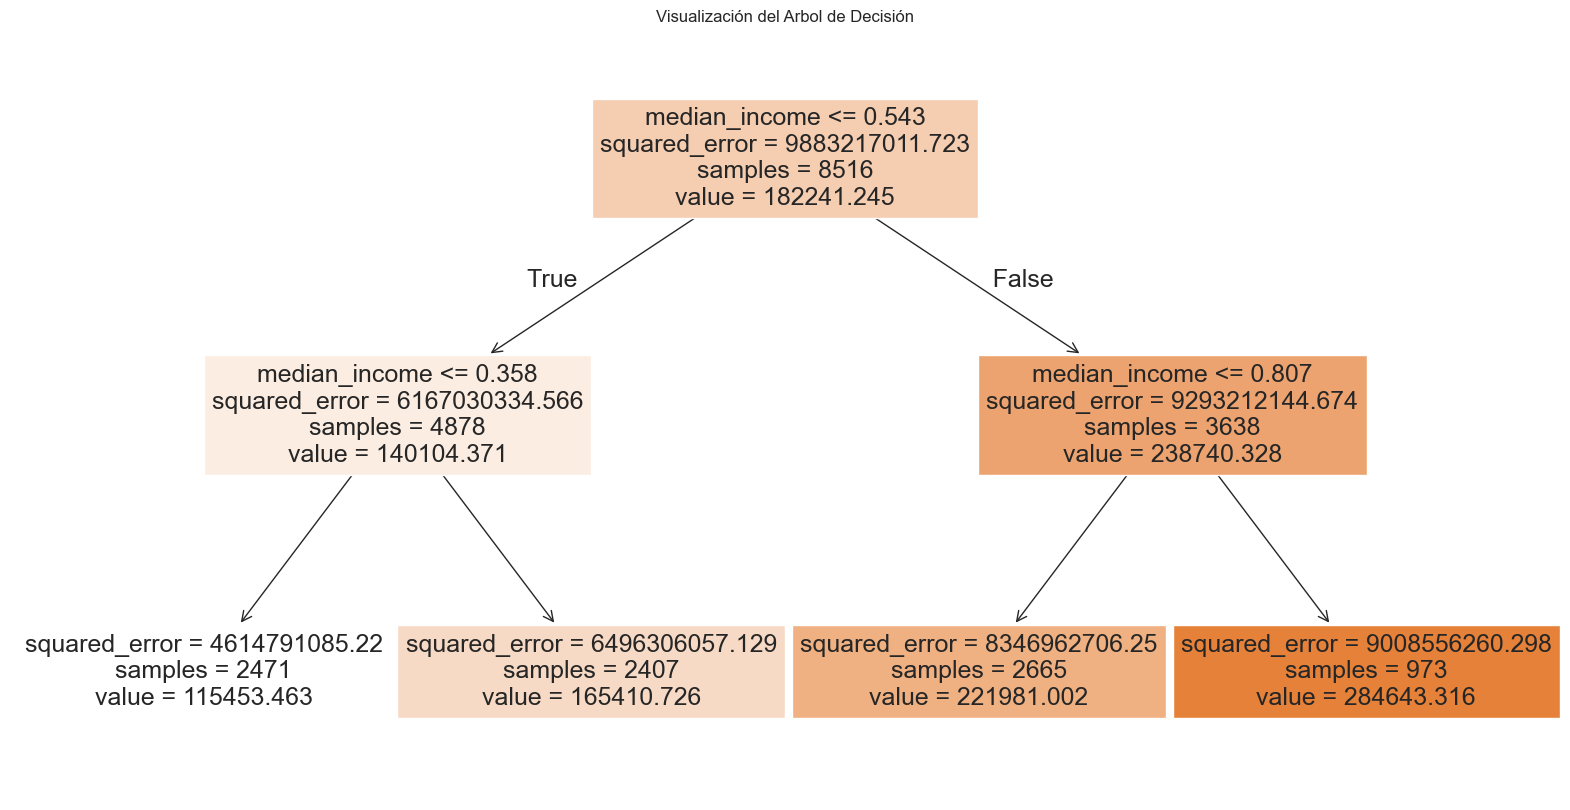

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(tree_mod,filled=True,feature_names=['housing_median_age','total_rooms','total_bedrooms','population','households','median_income'],class_names=True)
plt.title("Visualización del Arbol de Decisión")
plt.show()

## 8. SVR (Support Vector Regression)

Comparamos kernels (rbf/sigmoid/poly) y `C`.

In [ ]:
from sklearn.svm import SVR

In [ ]:
model=SVR()

In [ ]:
model.fit(x_train,y_train)

SVR()

In [ ]:
preds=model.predict(x_test)

In [ ]:
reg_score=r2_score(y_test,preds)
print(reg_score)

mse=mean_squared_error(y_test,preds)
print(mse)

rmse=mse**0.5
print(rmse*100)

-0.030148645569980204
9857451000.529018
9928469.670865202


In [ ]:
model=SVR(C=0.1)



In [ ]:
model.fit(x_train,y_train)
preds=model.predict(x_test)

In [ ]:
reg_score=r2_score(y_test,preds)
print(reg_score)

mse=mean_squared_error(y_test,preds)
print(mse)

rmse=mse**0.5
print(rmse*100)

-0.035558657745957456
9909219189.679482
9954506.110139007


In [ ]:
model=SVR(kernel='sigmoid')
model.fit(x_train,y_train)
preds=model.predict(x_test)



In [ ]:
reg_score=r2_score(y_test,preds)
print(reg_score)

mse=mean_squared_error(y_test,preds)
print(mse)

rmse=mse**0.5
print(rmse*100)

-0.03603756767378097
9913801859.537361
9956807.650817284


In [ ]:
model=SVR(kernel='poly')
model.fit(x_train,y_train)
preds=model.predict(x_test)


In [ ]:
reg_score=r2_score(y_test,preds)
print(reg_score)

mse=mean_squared_error(y_test,preds)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.3563182083962366
6159365202.2481785
7848162.334106104


## 9. Random Forest

Variando `n_estimators`, `max_depth`, `max_features`.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model=RandomForestRegressor()

In [ ]:
model.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
preds=model.predict(x_test)

In [ ]:
reg_score=r2_score(y_test,preds)
print(reg_score)

mse=mean_squared_error(y_test,preds)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.5282767420382325
4513900902.714092
6718557.064365898


In [ ]:
model=RandomForestRegressor(n_estimators=200)
model.fit(x_train,y_train)
preds=model.predict(x_test)

In [ ]:
reg_score=r2_score(y_test,preds)
print(reg_score)

mse=mean_squared_error(y_test,preds)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.5266246305041581
4529709891.605726
6730311.947900875


In [ ]:
model=RandomForestRegressor(max_depth=5)
model.fit(x_train,y_train)
preds=model.predict(x_test)

In [ ]:
reg_score=r2_score(y_test,preds)
print(reg_score)

mse=mean_squared_error(y_test,preds)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.5260278174344024
4535420771.891684
6734553.267954515


In [ ]:
model=RandomForestRegressor(max_features=4)
model.fit(x_train,y_train)
preds=model.predict(x_test)

In [ ]:
reg_score=r2_score(y_test,preds)
print(reg_score)

mse=mean_squared_error(y_test,preds)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.5275546764260306
4520810319.546369
6723697.137398715


## 10. XGBoost

Variando `n_estimators`, `max_depth`, `learning_rate`.

In [ ]:
from xgboost import XGBRegressor

In [ ]:
model=XGBRegressor()

In [ ]:
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
preds=model.predict(x_test)

In [ ]:
reg_score=r2_score(y_test,preds)
print(reg_score)

mse=mean_squared_error(y_test,preds)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.5028678351472036
4757037711.884713
6897128.1790936105


In [ ]:
model=XGBRegressor(n_estimators=30)
model.fit(x_train,y_train)
preds=model.predict(x_test)

reg_score=r2_score(y_test,preds)
print(reg_score)

mse=mean_squared_error(y_test,preds)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.5256263542741354
4539262356.742441
6737404.809526025


In [ ]:
model=XGBRegressor(max_depth=3)
model.fit(x_train,y_train)
preds=model.predict(x_test)

reg_score=r2_score(y_test,preds)
print(reg_score)

mse=mean_squared_error(y_test,preds)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.5406073430382872
4395909877.158882
6630165.817804922


In [ ]:
model=XGBRegressor(learning_rate=0.001)
model.fit(x_train,y_train)
preds=model.predict(x_test)

reg_score=r2_score(y_test,preds)
print(reg_score)

mse=mean_squared_error(y_test,preds)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.079080755916899
8812239246.279442
9387352.793135796


In [ ]:
model=XGBRegressor(learning_rate=0.1)
model.fit(x_train,y_train)
preds=model.predict(x_test)

reg_score=r2_score(y_test,preds)
print(reg_score)

mse=mean_squared_error(y_test,preds)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.540436526823662
4397544410.65364
6631398.352273554


In [ ]:
model=XGBRegressor(learning_rate=0.1,max_depth=3,n_estimators=30)
model.fit(x_train,y_train)
preds=model.predict(x_test)

reg_score=r2_score(y_test,preds)
print(reg_score)

mse=mean_squared_error(y_test,preds)
print(mse)

rmse=mse**0.5
print(rmse*100)

0.46022686843236105
5165067409.1661
7186840.341322535


## 11. Validación cruzada

Comparamos XGBoost y Random Forest con CV de 10 folds.

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer

folds=10

scoring = { 'r2_score': make_scorer(r2_score),
           'mae': make_scorer(mean_absolute_error),
           'mse': make_scorer(mean_squared_error)}

xgb_model = XGBRegressor()
xgb=cross_validate(xgb_model,x,y,cv=folds,scoring=scoring)

In [ ]:
pd.DataFrame(xgb).sort_values('test_r2_score')

,fit_time,score_time,test_r2_score,test_mae,test_mse
1,0.245930,0.007980,-1.215238,53366.144929,4.534302e+09
6,0.268826,0.006980,-0.246610,51615.913722,4.925189e+09
8,0.347648,0.013483,0.175124,67408.535310,8.147408e+09
0,0.329738,0.006998,0.197490,49981.351399,4.532198e+09
5,0.361117,0.006982,0.315900,53241.573291,5.306212e+09
9,0.311755,0.005966,0.341943,46516.415797,3.898597e+09
3,0.265339,0.005985,0.357633,41087.178163,3.405210e+09
7,0.323712,0.008975,0.439937,60833.875292,6.832913e+09
2,0.304774,0.006981,0.488424,54078.188928,5.985816e+09
4,0.564121,0.005983,0.537786,52521.577791,5.308605e+09


In [ ]:
rf_model=RandomForestRegressor()
rf=cross_validate(rf_model,x,y,cv=folds,scoring=scoring)
pd.DataFrame(rf).sort_values('test_r2_score')

,fit_time,score_time,test_r2_score,test_mae,test_mse
1,8.854435,0.045429,-1.173491,53615.737839,4.448852e+09
6,9.026348,0.042356,-0.169336,51319.456875,4.619891e+09
8,8.778540,0.043886,0.202130,66205.610666,7.880660e+09
0,9.651330,0.049829,0.291164,46497.275127,4.003168e+09
5,8.971686,0.049868,0.295136,51810.574536,5.467264e+09
9,8.688609,0.039928,0.347645,46133.320115,3.864811e+09
3,8.731948,0.043883,0.416326,38803.564552,3.094076e+09
7,8.814571,0.042879,0.441295,60670.904309,6.816344e+09
2,8.824556,0.042969,0.485901,53007.322892,6.015342e+09
4,8.767328,0.043886,0.526194,52978.154158,5.441737e+09


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
help(RandomForestRegressor)

Help on class RandomForestRegressor in module sklearn.ensemble._forest:

class RandomForestRegressor(ForestRegressor)
 |  RandomForestRegressor(n_estimators=100, *, criterion='squared_error', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=1.0, max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)
 |
 |  A random forest regressor.
 |
 |  A random forest is a meta estimator that fits a number of decision tree
 |  regressors on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to passing
 |  `splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeRegressor`.
 |  The sub-sample size is controlled with the `max_samples` parameter if
 |  `bootstrap=Tru

## 12. Ajuste de hiperparámetros

`GridSearchCV` y `RandomizedSearchCV` para Random Forest y XGBoost.

In [ ]:
param_grid= { 
    'max_depth': [3,5],
    'max_features': [2,3],
    'n_estimators': [100,200,300]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

model=RandomForestRegressor(random_state=0)

cv=GridSearchCV(model,param_grid,scoring='r2',cv=3)
cv.fit(x,y)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=0),
             param_grid={'max_depth': [3, 5], 'max_features': [2, 3],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [ ]:
resultados = pd.DataFrame(cv.cv_results_)
resultados[['params','mean_test_score','std_test_score','rank_test_score']]

,params,mean_test_score,std_test_score,rank_test_score
0,"{'max_depth': 3, 'max_features': 2, 'n_estimat...",0.278735,0.000571,12
1,"{'max_depth': 3, 'max_features': 2, 'n_estimat...",0.279082,0.002734,10
2,"{'max_depth': 3, 'max_features': 2, 'n_estimat...",0.279067,0.002989,11
3,"{'max_depth': 3, 'max_features': 3, 'n_estimat...",0.324444,0.015160,9
4,"{'max_depth': 3, 'max_features': 3, 'n_estimat...",0.325475,0.015182,7
5,"{'max_depth': 3, 'max_features': 3, 'n_estimat...",0.325178,0.015577,8
6,"{'max_depth': 5, 'max_features': 2, 'n_estimat...",0.374391,0.011499,6
7,"{'max_depth': 5, 'max_features': 2, 'n_estimat...",0.376444,0.011171,5
8,"{'max_depth': 5, 'max_features': 2, 'n_estimat...",0.376614,0.011674,4
9,"{'max_depth': 5, 'max_features': 3, 'n_estimat...",0.395461,0.019653,3


In [ ]:
cv.best_params_

{'max_depth': 5, 'max_features': 3, 'n_estimators': 300}

In [ ]:
best_model=cv.best_estimator_

In [ ]:
best_model

RandomForestRegressor(max_depth=5, max_features=3, n_estimators=300,
                      random_state=0)

In [ ]:
model=XGBRegressor()

cv= GridSearchCV(model, param_grid, scoring='r2',cv=3)

In [ ]:
cv.fit(x,y)

c:\Users\DH\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [20:13:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "max_features" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\DH\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [20:13:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "max_features" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\DH\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [20:13:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "max_features" } are not used.

  warnings.w

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...ne,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             param_grid={'max_depth': [3, 5], 'max_features': [2, 3],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [ ]:
resultados = pd.DataFrame(cv.cv_results_)
resultados[['params','mean_test_score','std_test_score','rank_test_score']]

,params,mean_test_score,std_test_score,rank_test_score
0,"{'max_depth': 3, 'max_features': 2, 'n_estimat...",0.492434,0.020725,1
1,"{'max_depth': 3, 'max_features': 2, 'n_estimat...",0.484298,0.019288,3
2,"{'max_depth': 3, 'max_features': 2, 'n_estimat...",0.474339,0.018193,5
3,"{'max_depth': 3, 'max_features': 3, 'n_estimat...",0.492434,0.020725,1
4,"{'max_depth': 3, 'max_features': 3, 'n_estimat...",0.484298,0.019288,3
5,"{'max_depth': 3, 'max_features': 3, 'n_estimat...",0.474339,0.018193,5
6,"{'max_depth': 5, 'max_features': 2, 'n_estimat...",0.466661,0.010319,7
7,"{'max_depth': 5, 'max_features': 2, 'n_estimat...",0.439669,0.013947,9
8,"{'max_depth': 5, 'max_features': 2, 'n_estimat...",0.425761,0.013169,11
9,"{'max_depth': 5, 'max_features': 3, 'n_estimat...",0.466661,0.010319,7


In [ ]:
cv.best_params_

{'max_depth': 3, 'max_features': 2, 'n_estimators': 100}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_random= {
    'max_depth':[3,5],
    'max_features':[2,3],
    'n_estimators':[100,200,300]
}

model= RandomForestRegressor(random_state=0)

cv=RandomizedSearchCV(model,param_random,n_iter=5,cv=3,random_state=0)
cv.fit(x,y)

RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=0),
                   n_iter=5,
                   param_distributions={'max_depth': [3, 5],
                                        'max_features': [2, 3],
                                        'n_estimators': [100, 200, 300]},
                   random_state=0)

In [ ]:
resultados = pd.DataFrame(cv.cv_results_)
resultados[['params','mean_test_score','std_test_score','rank_test_score']]

,params,mean_test_score,std_test_score,rank_test_score
0,"{'n_estimators': 100, 'max_features': 2, 'max_...",0.374391,0.011499,3
1,"{'n_estimators': 300, 'max_features': 3, 'max_...",0.396386,0.019843,1
2,"{'n_estimators': 200, 'max_features': 3, 'max_...",0.325475,0.015182,4
3,"{'n_estimators': 200, 'max_features': 3, 'max_...",0.395858,0.019751,2
4,"{'n_estimators': 300, 'max_features': 2, 'max_...",0.279067,0.002989,5


In [ ]:
cv.best_estimator_

RandomForestRegressor(max_depth=5, max_features=3, n_estimators=300,
                      random_state=0)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model=RandomForestRegressor()

In [ ]:
model.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
preds= model.predict(x_test)

In [ ]:
reg_score=r2_score(y_test,preds)
print(reg_score)
mse=mean_squared_error(y_test,preds)
print(mse)
rmse=mse**0.5
print(rmse*100)

0.5276987614046016
4519431576.175415
6722671.772573324


In [ ]:
model=RandomForestRegressor(n_estimators=200)

model.fit(x_train,y_train)


RandomForestRegressor(n_estimators=200)

In [ ]:
preds=model.predict(x_test)
reg_score=r2_score(y_test,preds)
print(reg_score)
mse=mean_squared_error(y_test,preds)
print(mse)
rmse=mse**0.5
print(rmse*100)

0.5285612006202884
4511178929.971271
6716531.046582953


In [ ]:
model=RandomForestRegressor(max_depth=5)
model.fit(x_train,y_train)
preds=model.predict(x_test)
reg_score=r2_score(y_test,preds)
print(reg_score)
mse=mean_squared_error(y_test,preds)
print(mse)
rmse=mse**0.5
print(rmse*100)


0.44858608952226575
5276457554.857904
7263922.876007085
